In [26]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
hdu = fits.open(f'../../atmos/BIFROST_en024048_hion_lgtg_385.fits')
nx = 504
ny = 504
nz = 425
x_size = 24 #Mm
y_size = 24 #Mm

In [ ]:
def read_geometry(filename):
    # Open the file in binary read mode
    with open(filename, 'rb') as f:
        
        # --- Section 1: Dimensions ---
        # "3 integers (4 bytes) con las dimensiones de los ejes X, Y y Z"
        # We use '<i4' for little-endian 32-bit integers
        dims = np.fromfile(f, dtype='<i4', count=3)
        nx, ny, nz = dims
        
        # --- Section 2: Resolution/Size ---
        # "3 floats (4 bytes) con bien la resolución espacial..."
        # We use '<f4' for little-endian 32-bit floats
        deltas = np.fromfile(f, dtype='<f4', count=3)
        dx, dy, dz = deltas
        
        # --- Section 3: Axes Data ---
        # The email says:
        # "NX floats... con el eje X"
        # "NY floats... con el eje Y"
        # "NZ floats... con el eje Z"
        
        x_axis = np.fromfile(f, dtype='<f4', count=nx)
        y_axis = np.fromfile(f, dtype='<f4', count=ny)
        z_axis = np.fromfile(f, dtype='<f4', count=nz)
        
    return {
        'nx': nx, 'ny': ny, 'nz': nz,
        'dx': dx, 'dy': dy, 'dz': dz,
        'x': x_axis, 
        'y': y_axis, 
        'z': z_axis
    }

# Usage
geo_data = read_geometry('/dat/andreuva/gpu/graphnet/data_porta/AR_385_GEOMETRY.dat')
print(f"Dimensions: {geo_data['nx']}, {geo_data['ny']}, {geo_data['nz']}")
z_geo = geo_data['z']

Dimensions: 504, 504, 496


In [ ]:
a

()

In [29]:
hdu[0].data.shape

(496, 504, 504)

In [30]:
hdu[1].data.shape

(496,)

In [31]:
z_range = hdu[1].data
z_steps = -z_range[:-1] + z_range[1:]

In [32]:
z = z_range[52:476+1]
xz = np.arange(52, 477)

array([-0.5136261 , -0.49441066, -0.47526246, -0.4561722 , -0.4371338 ,
       -0.4181381 , -0.3991745 , -0.3802292 , -0.36129147, -0.34235233,
       -0.323407  , -0.3044525 , -0.2854874 , -0.26651   , -0.2475204 ,
       -0.2285217 , -0.2095154 , -0.1904999 , -0.1714768 , -0.1524399 ,
       -0.1333893 , -0.1143265 , -0.09525451, -0.07618102, -0.05711212,
       -0.03805237, -0.0190094 , -0.        ,  0.01893768,  0.03772888,
        0.05637054,  0.07498322,  0.09367218,  0.1125046 ,  0.1315727 ,
        0.1508987 ,  0.1703682 ,  0.1898827 ,  0.20940779,  0.2289307 ,
        0.2484405 ,  0.2679375 ,  0.2874252 ,  0.3069069 ,  0.326384  ,
        0.3458618 ,  0.36534727,  0.3848412 ,  0.404348  ,  0.4238785 ,
        0.4434441 ,  0.4630516 ,  0.4827118 ,  0.5024383 ,  0.522242  ,
        0.542041  ,  0.5618347 ,  0.5816299 ,  0.6014381 ,  0.62127   ,
        0.6410424 ,  0.6608596 ,  0.6807274 ,  0.7006424 ,  0.720594  ,
        0.7405722 ,  0.7605667 ,  0.78056645,  0.8005661 ,  0.82

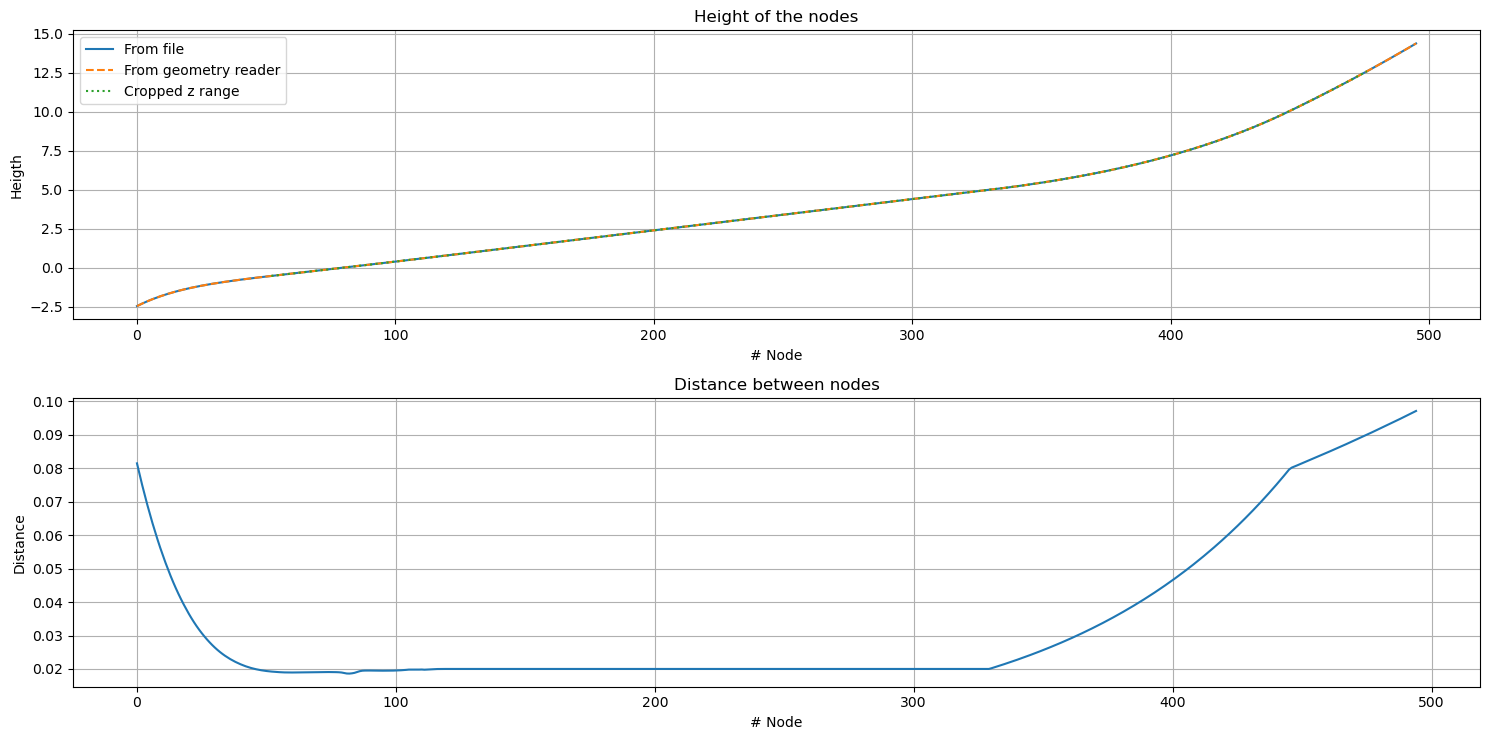

In [34]:
plt.figure(0,(15,7.5))
plt.subplot(2,1,1)
plt.plot(z_range, label='From file')
plt.plot(z_geo/1e8, label='From geometry reader', linestyle='dashed')
plt.plot(xz, z, label='Cropped z range', linestyle='dotted')
plt.legend()
plt.title('Height of the nodes')
plt.xlabel('# Node')
plt.ylabel('Heigth')
plt.grid()

plt.subplot(2,1,2)
plt.plot(z_steps)
plt.title('Distance between nodes')
plt.xlabel('# Node')
plt.ylabel('Distance')
plt.grid()

plt.tight_layout()
plt.show()

In [35]:
x, y = np.linspace(0, x_size, nx), np.linspace(0, y_size, ny)

In [36]:
print(x.shape, y.shape, z.shape)

(504,) (504,) (425,)


In [37]:
# save the x, y, z in a file called grid_bifrost
np.savez_compressed('grid_bifrost.npz', x=x, y=y, z=z)